#### Dataset Description 

- This dataset contains financial and personal details of loan applicants.
- It is used to predict whether a loan application will be approved or rejected based on factors like income, credit score, assets, employment status, and loan amount.

- The dataset includes both numerical and categorical features related to the applicant’s financial background and loan information. The target column is loan_status, which indicates the final loan approval decision.

##### Important Features
- loan_id -> Unique ID assigned to each applicant
- no_of_dependents -> Number of family dependents
- education -> Education status of applicant
- self_employed -> Whether applicant is self-employed or not
- income_annum -> Annual income of applicant
- loan_amount -> Requested loan amount
- loan_term -> Duration of loan
- cibil_score -> Applicant credit score
- residential_assets_value -> Value of residential assets
- commercial_assets_value -> Value of commercial assets
- luxury_assets_value -> Value of luxury assets
- bank_asset_value -> Value of bank assets
- loan_status -> Loan approval status (Approved/Rejected)
##### Target Variable
- loan_status 
##### Total Columns
- The dataset contains 13 columns:
- 12 input features
- 1 target/output column (loan_status)

#### The objective of this project is to analyze applicant data, preprocess the dataset, and build a machine learning classification model capable of accurately predicting loan approval status.

# Import Python Libraries

In [274]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [275]:
#load dataset
df = pd.read_csv("loan_approval_dataset.csv")

In [276]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [277]:
df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [278]:
df.shape

(4269, 13)

In [279]:
# data understanding 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1   no_of_dependents           4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [280]:
df.isnull().sum()

loan_id                      0
no_of_dependents             0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [281]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.00,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.50,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.00,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.00,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.00,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [282]:
# 4.269000e+03 -> scientific notation.
# To make it readable we use -> set_option()
pd.set_option('display.float_format', '{:.2f}'.format)

In [283]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.00,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.50,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.00,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.00,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.00,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [284]:
df['loan_id'].count() # loan application in the dataset

np.int64(4269)

In [285]:
# What percentage of applicants get loan approved vs rejected?
df['loan_status'].value_counts()

KeyError: 'loan_status'

In [286]:
# removing spaces present at the start ( see info )
df.columns

Index(['loan_id', 'no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [287]:
df.columns = df.columns.str.strip()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [288]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [289]:
df['education'].unique()                          
# df['self_employed'].unique()
# df['loan_status'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [290]:
df['education'] = df['education'].str.strip()
df['self_employed'] = df['self_employed'].str.strip()
df['loan_status'] = df['loan_status'].str.strip()

In [291]:
df['education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [292]:
df['loan_status'].unique()

array(['Approved', 'Rejected'], dtype=object)

In [293]:
# What percentage of applicants get loan approved vs rejected?
df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [294]:
df['loan_status'].value_counts(normalize = True) *100

loan_status
Approved   62.22
Rejected   37.78
Name: proportion, dtype: float64

In [295]:
# changing the datatype of 'loan_id' column
df['loan_id'] = df['loan_id'].astype(str)

In [296]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   object
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(9), object(4)
memory usage: 433.7+ KB


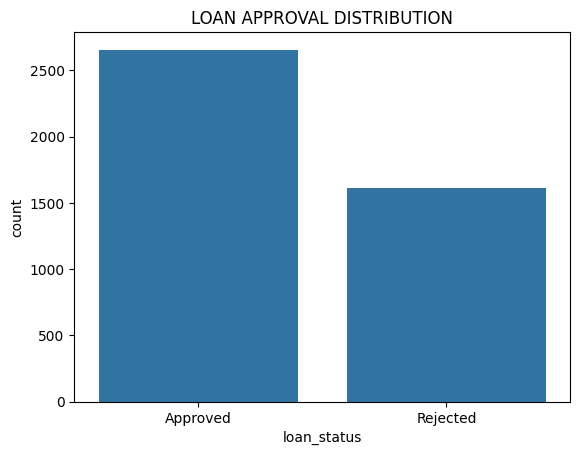

In [297]:
# Is the dataset balanced or imbalanced for loan approval?

sns.countplot(x = 'loan_status' , data = df)
plt.title("LOAN APPROVAL DISTRIBUTION")
plt.show()

####  Using Exploratory Data Analysis(EDA) -> Relationships Analyze Karne ke liye
- Check:-- Kaunsa feature loan approval ko affect karta h
- Example:
- High CIBIL → higher approval chances


## 1. Does Employment type affect loan approval?

In [298]:
#### Salaried People
# Usually: Fixed monthly income -> More stable earnings
# So approval chances can be higher.

#### Self-Employed People
# Income may: Vary monthly -> Be less predictable
# So banks may consider them slightly riskier.

In [299]:
df['self_employed'].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [300]:
df.groupby(['self_employed', 'loan_status'])['loan_status'].count()
# This code counts how many applicants were approved or rejected based on employment type.
## Self-employed = Yes → kitne approved/rejected
## Self-employed = No → kitne approved/rejected

self_employed  loan_status
No             Approved       1318
               Rejected        801
Yes            Approved       1338
               Rejected        812
Name: loan_status, dtype: int64

In [301]:
emp_status = df.groupby(['self_employed', 'loan_status'])['loan_status'].count().unstack()

# unstack() is used to convert grouped row labels into columns for better readability and analysis.
# It is commonly used after groupby().

emp_status

loan_status,Approved,Rejected
self_employed,,
No,1318,801
Yes,1338,812


In [302]:
emp_status['Total'] = emp_status['Approved'] + emp_status['Rejected']
emp_status

loan_status,Approved,Rejected,Total
self_employed,,,
No,1318,801,2119
Yes,1338,812,2150


In [303]:
emp_status['Approved %'] = emp_status['Approved'] / emp_status['Total'] * 100
emp_status

loan_status,Approved,Rejected,Total,Approved %
self_employed,,,,
No,1318,801,2119,62.20
Yes,1338,812,2150,62.23


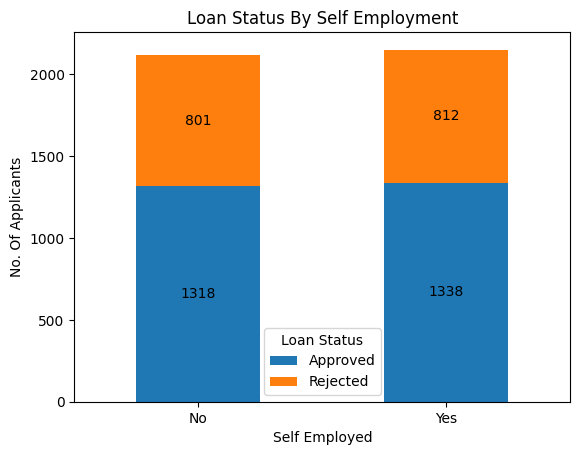

In [304]:
# Plot stacked bar chart

ax = emp_status[['Approved', 'Rejected']].plot(kind='bar', stacked= True)
plt.title("Loan Status By Self Employment")
plt.xlabel("Self Employed")
plt.ylabel("No. Of Applicants")
plt.xticks(rotation = 0)
plt.legend(title = "Loan Status")

for container in ax.containers:
    ax.bar_label(container, label_type = 'center')
plt.show()

In [305]:
#### The graph shows that loan approval percentages for self-employed and non-self-employed applicants are almost identical. Therefore, employment type does not strongly influence loan approval.


## 2. Do graduates get higher approval rates than non-gratuates??

In [306]:
df['education'].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [307]:
education_status = df.groupby(['education', 'loan_status'])['loan_status'].count().unstack()

education_status

loan_status,Approved,Rejected
education,,
Graduate,1339,805
Not Graduate,1317,808


In [308]:
education_status['Total'] = education_status['Approved'] + education_status['Rejected']
education_status['Approved %'] = education_status['Approved'] / education_status['Total'] * 100
education_status

loan_status,Approved,Rejected,Total,Approved %
education,,,,
Graduate,1339,805,2144,62.45
Not Graduate,1317,808,2125,61.98


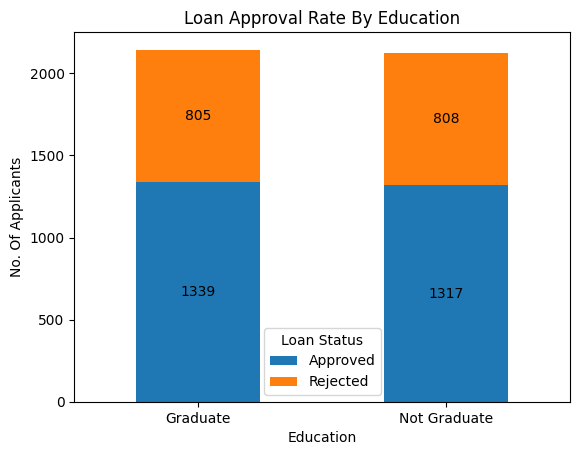

In [309]:
# Plot stacked bar chart

ax1 = education_status[['Approved', 'Rejected']].plot(kind='bar', stacked= True)
plt.title("Loan Approval Rate By Education")
plt.xlabel("Education")
plt.ylabel("No. Of Applicants")
plt.xticks(rotation = 0)
plt.legend(title = "Loan Status")

for container in ax1.containers:
    ax1.bar_label(container, label_type = 'center')
plt.show()

In [310]:
#### The graph shows that loan approval and rejection counts are very similar for both graduates and non-graduates. This indicates that education level does not strongly affect loan approval.


## 3. Does having more dependents reduce approval chances?

In [311]:
df['no_of_dependents'].value_counts()

no_of_dependents
4    752
3    727
0    712
2    708
1    697
5    673
Name: count, dtype: int64

In [312]:
dependent_status = df.groupby(['no_of_dependents', 'loan_status'])['loan_status'].count().unstack()

dependent_status

loan_status,Approved,Rejected
no_of_dependents,,
0,457,255
1,430,267
2,441,267
3,457,270
4,465,287
5,406,267


In [313]:
dependent_status['Total'] = dependent_status['Approved'] + dependent_status['Rejected']
dependent_status['Approved %'] = dependent_status['Approved'] / dependent_status['Total'] * 100
dependent_status

loan_status,Approved,Rejected,Total,Approved %
no_of_dependents,,,,
0,457,255,712,64.19
1,430,267,697,61.69
2,441,267,708,62.29
3,457,270,727,62.86
4,465,287,752,61.84
5,406,267,673,60.33


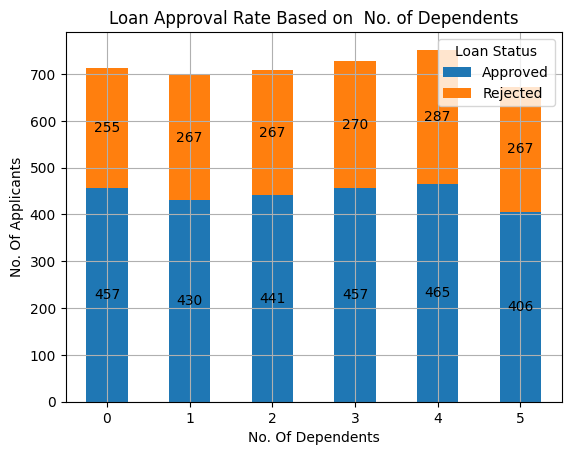

In [314]:
# Plot stacked bar chart

ax2 = dependent_status[['Approved', 'Rejected']].plot(kind='bar', stacked= True)
plt.title("Loan Approval Rate Based on  No. of Dependents")
plt.xlabel("No. Of Dependents")
plt.ylabel("No. Of Applicants")
plt.xticks(rotation = 0)
plt.legend(title = "Loan Status")
plt.grid()

for container in ax2.containers:
    ax2.bar_label(container, label_type = 'center')
plt.show()

In [315]:
#### The graph shows a slight decrease in loan approval percentage as the number of dependents increases. Applicants with fewer dependents have slightly higher approval rates, suggesting that the number of dependents may have a small influence on loan approval.


## 4. What is the relationship between applicant income and loan approval??

In [316]:
df['income_annum'].describe()

count      4269.00
mean    5059123.92
std     2806839.83
min      200000.00
25%     2700000.00
50%     5100000.00
75%     7500000.00
max     9900000.00
Name: income_annum, dtype: float64

In [317]:
x = df.groupby('loan_status').mean(numeric_only=True)['income_annum']
x

loan_status
Approved   5025903.61
Rejected   5113825.17
Name: income_annum, dtype: float64

In [318]:
type(x)

pandas.core.series.Series

<Axes: xlabel='loan_status'>

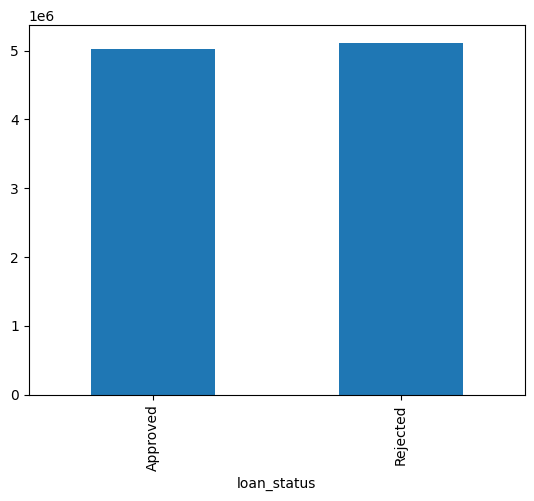

In [319]:
x.plot(kind = 'bar')

In [320]:
#### annual income does not strongly affect loan approval.

## 5. How does loan amount vary between approval and rejected loans??

In [321]:
df['loan_amount'].describe()

count       4269.00
mean    15133450.46
std      9043362.98
min       300000.00
25%      7700000.00
50%     14500000.00
75%     21500000.00
max     39500000.00
Name: loan_amount, dtype: float64

In [322]:
df.groupby('loan_status').mean(numeric_only = True)['loan_amount']

loan_status
Approved   15247251.51
Rejected   14946063.24
Name: loan_amount, dtype: float64

In [323]:
approved_amount = df[df['loan_status'] == 'Approved']['loan_amount']
rejected_amount = df[df['loan_status'] == 'Rejected']['loan_amount']
approved_amount

0       29900000
6       33000000
8        2200000
10      11200000
13      31500000
          ...   
4261     7500000
4263    12700000
4265    11300000
4267    12800000
4268    29700000
Name: loan_amount, Length: 2656, dtype: int64

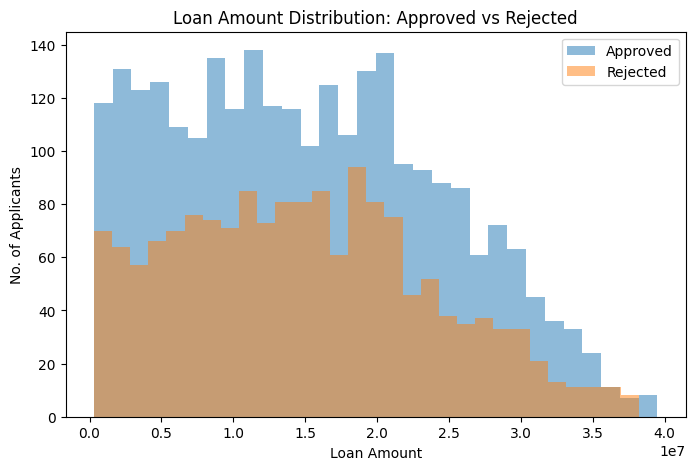

In [324]:
plt.figure(figsize =(8,5))
plt.hist( approved_amount, bins = 30 , alpha = 0.5, label ='Approved')
plt.hist( rejected_amount, bins = 30 , alpha = 0.5, label ='Rejected')

plt.title("Loan Amount Distribution: Approved vs Rejected")
plt.xlabel("Loan Amount")
plt.ylabel("No. of Applicants")
plt.legend()
plt.show()

## 6. Does the cibil score strongly influence loan approval?

In [325]:
df['cibil_score'].describe()

count   4269.00
mean     599.94
std      172.43
min      300.00
25%      453.00
50%      600.00
75%      748.00
max      900.00
Name: cibil_score, dtype: float64

In [326]:
df.groupby('loan_status').mean(numeric_only = True)['cibil_score']

loan_status
Approved   703.46
Rejected   429.47
Name: cibil_score, dtype: float64

In [327]:
approved_cibil = df[df['loan_status'] == 'Approved']['cibil_score']
rejected_cibil = df[df['loan_status'] == 'Rejected']['cibil_score']

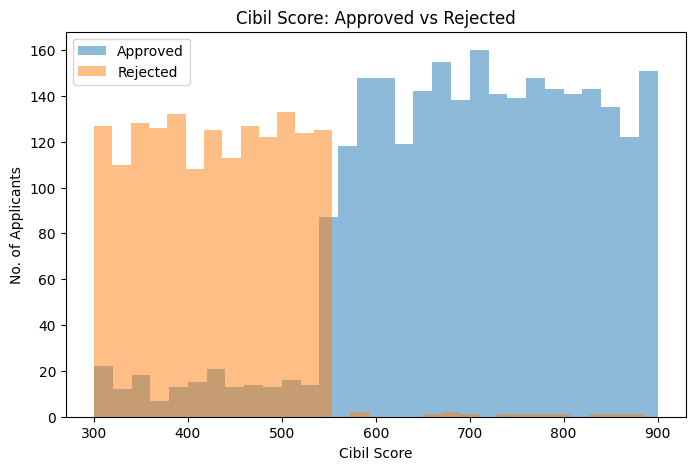

In [328]:
plt.figure(figsize =(8,5))
plt.hist( approved_cibil, bins = 30 , alpha = 0.5, label ='Approved')
plt.hist( rejected_cibil, bins = 30 , alpha = 0.5, label ='Rejected')

plt.title("Cibil Score: Approved vs Rejected")
plt.xlabel("Cibil Score")
plt.ylabel("No. of Applicants")
plt.legend()
plt.show()

# Data Visualization

## A. Compare Applicant income vs Loan Amount(Scatter plot)

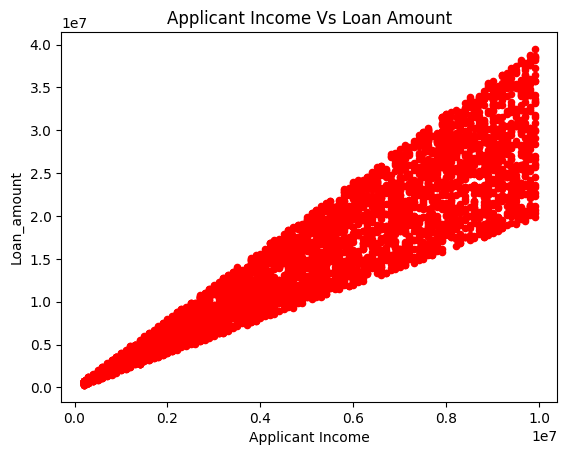

In [329]:
df.plot(x = 'income_annum', y = 'loan_amount', kind = 'scatter', color = 'red') 
plt.title("Applicant Income Vs Loan Amount")
plt.xlabel("Applicant Income")
plt.ylabel("Loan_amount")
plt.show()

## B.Correlation Heatmap of numerical features

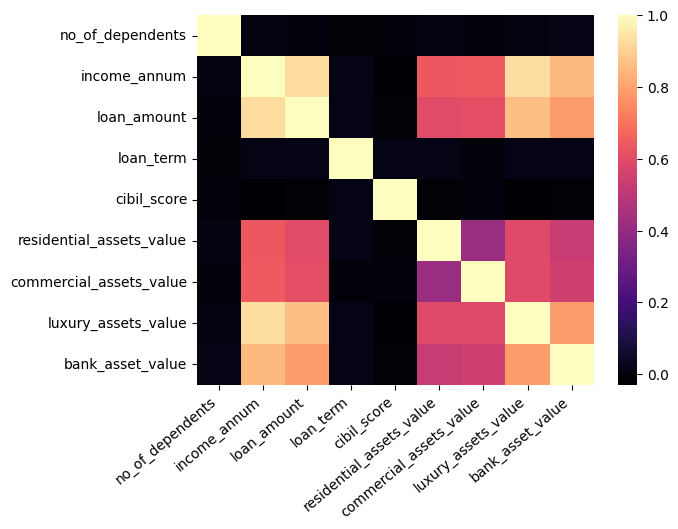

In [330]:
sns.heatmap(df.corr(numeric_only = True), cmap = 'magma' )
plt.xticks(rotation =  40, ha = 'right')
plt.show()

In [331]:
df['loan_amount'].corr(df['income_annum'])

np.float64(0.9274699109871488)

In [332]:
df['luxury_assets_value'].corr(df['income_annum'])

np.float64(0.9291454207522586)

# Data Cleaning & Feature Engineering

In [333]:
# Detect outliers
# Remove outliers
# Which features should be dropped
# Convert catergorical variables into numeric using Maping, Label Encoding & One-Hot Encoding
# Scale numerical features before model training

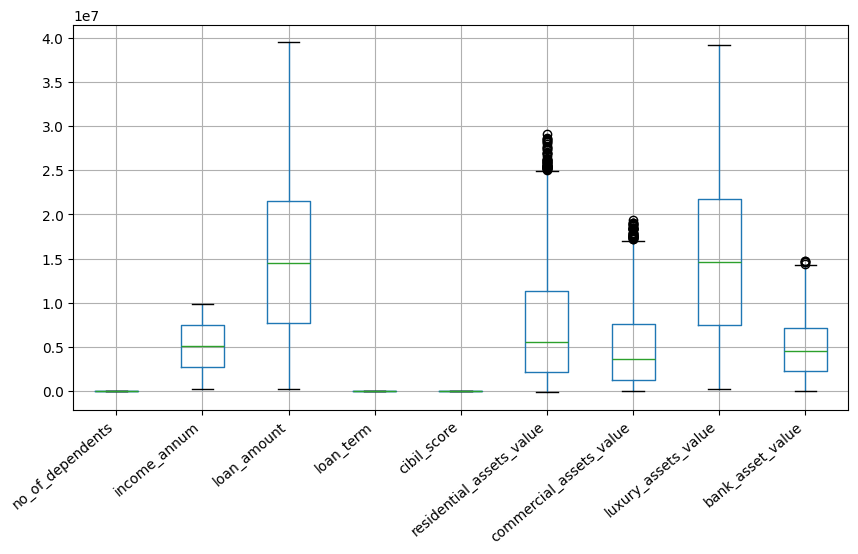

In [334]:
plt.figure(figsize = (10,5))
df.boxplot()
plt.xticks(rotation =  40, ha = 'right')
plt.show()

#This code creates boxplots for all numerical columns to analyze data distribution and detect outliers.

In [335]:
## Remove residential_asset_values outliers
R_Q1 = df['residential_assets_value'].quantile(0.25)
R_Q3 = df['residential_assets_value'].quantile(0.75)

#calculate IQR
IQR = R_Q3 - R_Q1
IQR # Interquartile Range

# Lower limit:
## Q1−1.5×IQR

# Upper limit:
## Q3+1.5×IQR

# Is range ke bahar values: Outliers considered hoti hain.

np.float64(9100000.0)

In [336]:
lower_limit = R_Q1 - 1.5 * IQR
upper_limit = R_Q3 + 1.5 * IQR

In [337]:
df = df[(df['residential_assets_value'] >= lower_limit) & (df['residential_assets_value'] <= upper_limit)]

In [338]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


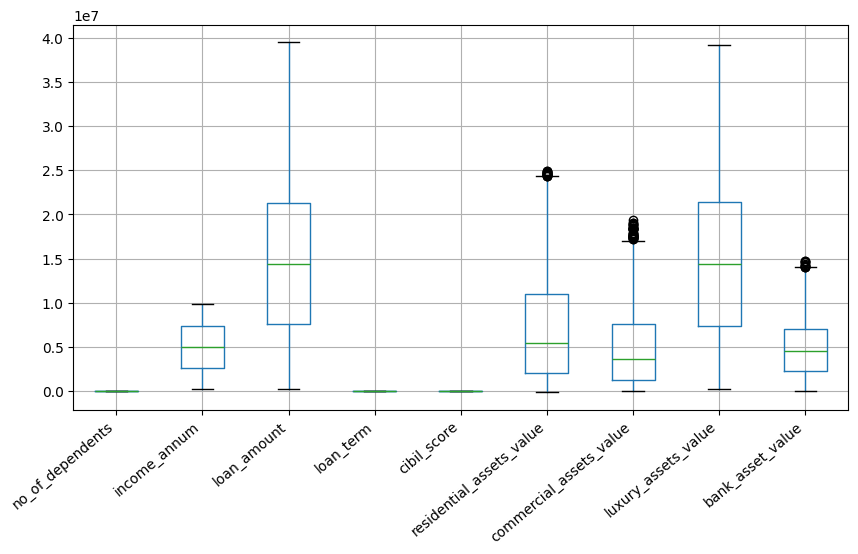

In [339]:
plt.figure(figsize = (10,5))
df.boxplot()
plt.xticks(rotation =  40, ha = 'right')
plt.show()

In [340]:
## Remove commercial_assets_values outliers
C_Q1 = df['commercial_assets_value'].quantile(0.25)
C_Q3 = df['commercial_assets_value'].quantile(0.75)

#calculate IQR
IQR = C_Q3 - C_Q1
IQR 

np.float64(6300000.0)

In [342]:
lower_limit = C_Q1 - 1.5 * IQR
upper_limit = C_Q3 + 1.5 * IQR
df = df[(df['commercial_assets_value'] >= lower_limit) & (df['commercial_assets_value'] <= upper_limit)]
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


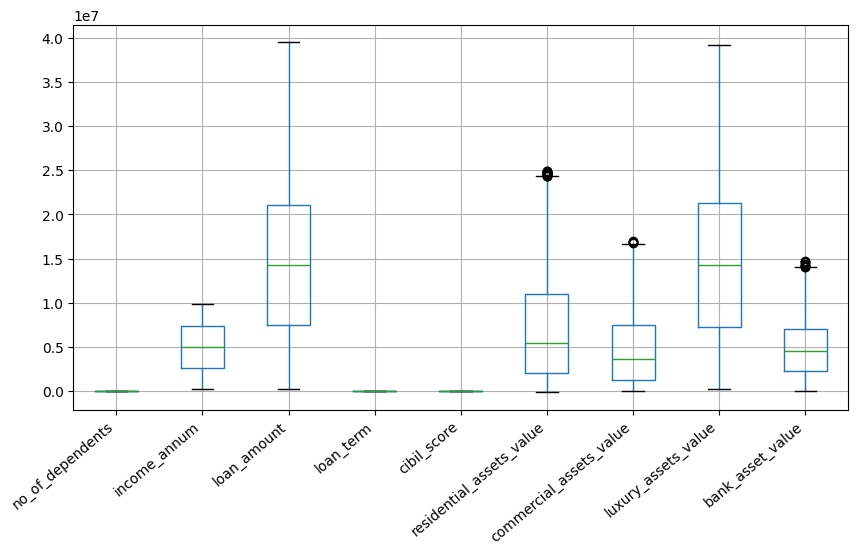

In [343]:
plt.figure(figsize = (10,5))
df.boxplot()
plt.xticks(rotation =  40, ha = 'right')
plt.show()

In [345]:
## Remove bank_asset_values outliers
B_Q1 = df['bank_asset_value'].quantile(0.25)
B_Q3 = df['bank_asset_value'].quantile(0.75)

#calculate IQR
IQR = B_Q3 - B_Q1
IQR 

np.float64(4700000.0)

In [347]:
lower_limit = B_Q1 - 1.5 * IQR
upper_limit = B_Q3 + 1.5 * IQR
df = df[(df['bank_asset_value'] >= lower_limit) & (df['bank_asset_value'] <= upper_limit)]
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


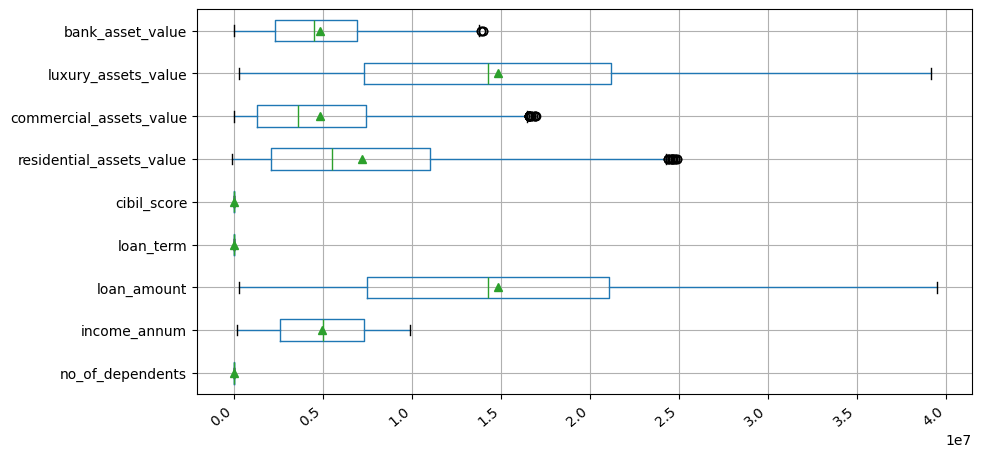

In [351]:
plt.figure(figsize = (10,5))
df.boxplot(showmeans = True , vert = False)
plt.xticks(rotation =  40, ha = 'right')
plt.show()

In [353]:
### which features should be removed?
df = df.drop('loan_id', axis = 1)
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [354]:
### Converting categorical values -> numerical values

##### Mapping

In [357]:
df['loan_status'] = df['loan_status'].map({'Approved' : 1, 'Rejected' : 0})

In [358]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


##### Label Encoding

In [361]:
# Encode Binary Columns

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['self_employed'] = le.fit_transform(df['self_employed'])

In [362]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,Not Graduate,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,Not Graduate,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,Not Graduate,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


##### One-Hot Encoding

In [363]:
from sklearn.preprocessing import OneHotEncoder

In [367]:
df = pd.get_dummies(df, columns = ['education']).astype(int)
df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,0,1
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,1,0
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,1,0
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,0,1
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,1,0
4265,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,0,1
4266,2,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,0,1
4267,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,0,1


## Feature Scaling
- Feature scaling is essential for models like logistic Regression and SVM , but not required for tree-based models. However, I applied scaling to ensure consistency and fair model comparison.

In [370]:
from sklearn.preprocessing import StandardScaler

In [374]:
scaler = StandardScaler()
numeric_cols = ['income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [375]:
df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,-0.31,-0.30,-0.51,-1.06,-0.73,-0.62,-0.67,-0.49,0,0,1
2,3,0,1.50,1.66,1.60,-0.55,-0.01,-0.08,2.05,2.51,0,1,0
3,3,0,1.18,1.78,-0.51,-0.77,1.80,-0.36,0.94,0.96,0,1,0
4,5,1,1.76,1.05,1.60,-1.27,0.85,0.80,1.62,0.04,0,0,1
5,0,1,-0.06,-0.15,-0.15,-1.63,-0.06,0.83,-0.13,0.07,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,-1.44,-1.41,0.20,-1.64,-0.71,-1.03,-1.29,-1.28,0,1,0
4265,0,1,-0.60,-0.40,1.60,-0.24,-0.49,-0.46,-0.43,-0.94,1,0,1
4266,2,0,0.56,1.01,1.25,-0.83,-0.97,1.80,0.36,0.77,0,0,1
4267,1,0,-0.31,-0.23,-0.51,1.04,0.17,-0.98,-0.08,0.30,1,0,1


## Model Building

In [385]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [393]:
x = df.drop(['loan_status'], axis = 1)
y = df['loan_status']

In [394]:
x

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_Graduate,education_Not Graduate
1,0,1,-0.31,-0.30,-0.51,-1.06,-0.73,-0.62,-0.67,-0.49,0,1
2,3,0,1.50,1.66,1.60,-0.55,-0.01,-0.08,2.05,2.51,1,0
3,3,0,1.18,1.78,-0.51,-0.77,1.80,-0.36,0.94,0.96,1,0
4,5,1,1.76,1.05,1.60,-1.27,0.85,0.80,1.62,0.04,0,1
5,0,1,-0.06,-0.15,-0.15,-1.63,-0.06,0.83,-0.13,0.07,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,-1.44,-1.41,0.20,-1.64,-0.71,-1.03,-1.29,-1.28,1,0
4265,0,1,-0.60,-0.40,1.60,-0.24,-0.49,-0.46,-0.43,-0.94,0,1
4266,2,0,0.56,1.01,1.25,-0.83,-0.97,1.80,0.36,0.77,0,1
4267,1,0,-0.31,-0.23,-0.51,1.04,0.17,-0.98,-0.08,0.30,0,1


In [391]:
y

1       0
2       0
3       0
4       0
5       0
       ..
4264    0
4265    1
4266    0
4267    1
4268    1
Name: loan_status, Length: 4173, dtype: int64

In [396]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 39)
#random_state fixes randomness so results remain reproducible every time the code runs.

In [404]:
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}

for name, model in models.items():
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    print(name, "Accuracy:", accuracy_score(y_test, preds))

Logistic Regression Accuracy: 0.9041916167664671
Decision Tree Accuracy: 0.9760479041916168
Random Forest Accuracy: 0.9760479041916168
XGBoost Accuracy: 0.9820359281437125


In [403]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


- Among all the machine learning models tested, XGBoost achieved the highest accuracy of 98.20%, making it the best-performing model for loan approval prediction. Logistic Regression showed comparatively lower performance, while Decision Tree and Random Forest also produced strong results.


In [412]:
results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    acc = accuracy_score(y_test, preds)

    results.append([name, round(acc * 100, 2)])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy (%)'])

# Colorful styled table
results_df.style\
    .hide(axis='index')\
    .background_gradient(cmap='viridis', subset=['Accuracy (%)'])\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '14px',
        'border': '1px solid black'
    })\
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#2E4053'),
                ('color', 'white'),
                ('font-size', '15px'),
                ('text-align', 'center')
            ]
        }
    ])

Model,Accuracy (%)
Logistic Regression,90.420000
Decision Tree,97.600000
Random Forest,97.600000
XGBoost,98.200000


<Figure size 600x500 with 0 Axes>

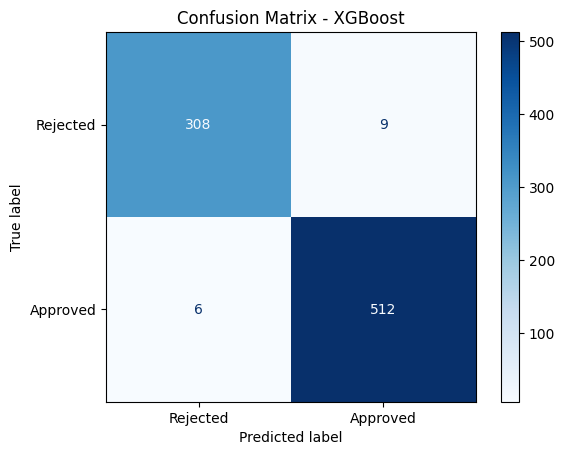

<Figure size 640x480 with 0 Axes>

In [409]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Best model (XGBoost)
best_model = XGBClassifier()

# Train model
best_model.fit(x_train, y_train)

# Predictions
y_pred = best_model.predict(x_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Rejected', 'Approved'])

plt.figure(figsize=(6,5))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.show()

plt.savefig("confusion_matrix.png", bbox_inches='tight')